In [1]:
import json
import pandas as pd

data_path = '../data/meta_data_annotation_all_features_220523.json'

In [2]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn import naive_bayes, svm
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix
import seaborn as sn
import matplotlib.pyplot as plt

In [3]:
df = pd.read_json(data_path, orient='index')
df.head()

,name,annotates,sampleRate,utterance,utt,spn,o_utt,item,o_item,alc,...,aak,bak,ges,ces,wea,irreg,anncom,specom,type,content
../../data/ALC/ses4038/5444038020_h_00_annot.json,5444038020_h_00,5444038020_h_00.wav,44100,5444038020_h_00,5444038020,544,5443046020,20,020,na,...,0.0,0.0,f5,r1,SUN,1|0|0|0|0|1|0|0|0,null,null,R,T
../../data/ALC/ses4038/5444038033_h_00_annot.json,5444038033_h_00,5444038033_h_00.wav,44100,5444038033_h_00,5444038033,544,null,33,null,na,...,0.0,0.0,f5,r1,SUN,0|0|0|0|0|0|0|0|0,null,null,R,A
../../data/ALC/ses4038/5444038035_h_00_annot.json,5444038035_h_00,5444038035_h_00.wav,44100,5444038035_h_00,5444038035,544,null,35,null,na,...,0.0,0.0,f5,r1,SUN,9999|0|0|0|0|0|0|0|0,null,null,L,N
../../data/ALC/ses4038/5444038060_h_00_annot.json,5444038060_h_00,5444038060_h_00.wav,44100,5444038060_h_00,5444038060,544,5443046030,60,030,na,...,0.0,0.0,f5,r1,SUN,9999|0|0|0|0|0|0|0|0,null,null,L,S
../../data/ALC/ses4038/5444038026_h_00_annot.json,5444038026_h_00,5444038026_h_00.wav,44100,5444038026_h_00,5444038026,544,5443046006,26,006,na,...,0.0,0.0,f5,r1,SUN,9999|0|0|0|0|0|0|0|0,null,null,L,N


In [4]:
#questions: null values in o_utt column -- will be removed by Laura

In [5]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2)

In [6]:
test

,name,annotates,sampleRate,utterance,utt,spn,o_utt,item,o_item,alc,...,aak,bak,ges,ces,wea,irreg,anncom,specom,type,content
../../data/ALC/ses3024/5233024019_h_00_annot.json,5233024019_h_00,5233024019_h_00.wav,44100,5233024019_h_00,5233024019,523,5234023019,19,019,a,...,0.00069,0.00081,f10,r1,SUN,1|0|0|0|0|1|0|0|0,null,null,R,A
../../data/ALC/ses5009/0895009007_h_00_annot.json,0895009007_h_00,0895009007_h_00.wav,44100,0895009007_h_00,895009007,89,0892072023,7,023,cna,...,0.00000,0.00000,f5,r1,SUN,0|0|0|0|0|0|0|0|0,null,null,R,T
../../data/ALC/ses4027/5264027059_h_00_annot.json,5264027059_h_00,5264027059_h_00.wav,44100,5264027059_h_00,5264027059,526,5263027023,59,023,na,...,0.00000,0.00000,f6,r1,SUN,0|0|0|0|0|0|0|0|0,null,null,R,R
../../data/ALC/ses3053/5523053020_h_00_annot.json,5523053020_h_00,5523053020_h_00.wav,44100,5523053020_h_00,5523053020,552,5524031020,20,020,a,...,0.00095,0.00091,f5,r1,SUN,1|0|1|0|0|0|0|0|1,null,null,R,T
../../data/ALC/ses2083/0862083013_h_00_annot.json,0862083013_h_00,0862083013_h_00.wav,44100,0862083013_h_00,862083013,86,0861087013,13,013,na,...,0.00000,0.00000,f1,r1,SUN,0|0|0|0|0|0|0|0|0,null,null,R,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
../../data/ALC/ses2032/0172032002_h_00_annot.json,0172032002_h_00,0172032002_h_00.wav,44100,0172032002_h_00,172032002,17,null,2,null,na,...,0.00000,0.00000,f5,r1,SUN,2|2|1|4|0|0|1|0|0,null,null,D,Q
../../data/ALC/ses4056/5744056054_h_00_annot.json,5744056054_h_00,5744056054_h_00.wav,44100,5744056054_h_00,5744056054,574,null,54,null,na,...,0.00000,0.00000,f5,r1,SUN,9999|0|0|0|0|0|0|0|0,null,null,E,C
../../data/ALC/ses4081/5954081021_h_00_annot.json,5954081021_h_00,5954081021_h_00.wav,44100,5954081021_h_00,5954081021,595,null,21,null,na,...,0.00000,0.00000,f1,r1,SUN,9999|0|2|0|0|1|0|1|0,null,null,L,N
../../data/ALC/ses4043/5614043028_h_00_annot.json,5614043028_h_00,5614043028_h_00.wav,44100,5614043028_h_00,5614043028,561,null,28,null,na,...,0.00000,0.00000,f5,r1,SUN,0|0|0|0|0|0|0|0|0,null,null,R,A


In [7]:
label_to_idx = {"a":1, "cna":0, "na": 0}
X_train = [[x] for x in train['bak']] #replace with the actual feature column
y_train = [label_to_idx[x] for x in train['alc']]

X_test = [[x] for x in test['bak']] #replace with the actual feature column
y_test = [label_to_idx[x] for x in test['alc']]

In [8]:
def evaluate_classifier(classifier, X_test, y_test):
    y_predicted = classifier.predict(X_test)
    cm = confusion_matrix(y_test, y_predicted)
    sn.heatmap(cm, annot=True, fmt='g')
    plt.xlabel('Predicted')
    plt.ylabel('Expected')

In [9]:
nb_classifier = naive_bayes.BernoulliNB()
nb_classifier.fit(X_train, y_train)

BernoulliNB()

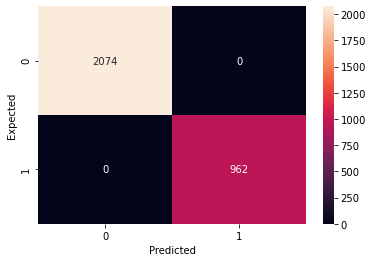

In [10]:
evaluate_classifier(nb_classifier, X_test, y_test)